In [3]:
!pip install -q minigrid

In [44]:
import os
import random
import shutil
from collections import defaultdict
from dataclasses import dataclass, replace
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import FileLink, display
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

@dataclass
class Config:
    env_id: str = "MiniGrid-Empty-6x6-v0"
    image_size: int = 64
    vlm_image_size: int = 224
    random_dataset_episodes: int = 450
    oracle_dataset_episodes: int = 250
    val_random_episodes: int = 40
    val_oracle_episodes: int = 40
    oracle_noise: float = 0.15
    max_steps: int = 64
    sequence_length: int = 32
    batch_size: int = 32
    train_steps: int = 6000
    learning_rate: float = 3e-4
    latent_size: int = 48
    deter_size: int = 192
    embed_size: int = 384
    action_embed_size: int = 32
    kl_scale: float = 0.15
    free_nats: float = 0.5
    reward_scale: float = 10.0
    continue_scale: float = 1.0
    prior_recon_scale: float = 0.35
    direction_scale: float = 0.25
    turn_penalty: float = 0.025
    time_penalty: float = 0.004
    grad_clip: float = 100.0
    planning_horizon: int = 10
    planning_candidates: int = 512
    planner_action_ids: tuple = (0, 1, 2)
    vlm_batch_size: int = 128
    vlm_score_frames: int = 5
    vlm_rerank: int = 64
    gamma: float = 0.95
    vlm_weight: float = 0.25
    reward_weight: float = 1.0
    eval_episodes: int = 20
    seed: int = 7
    output_dir: str = ""

cfg = Config()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

work_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
output_dir = work_dir / "outputs" if cfg.output_dir == "" else Path(cfg.output_dir)
(output_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
(output_dir / "gifs").mkdir(parents=True, exist_ok=True)
(output_dir / "metrics").mkdir(parents=True, exist_ok=True)
(output_dir / "report_assets").mkdir(parents=True, exist_ok=True)

print(f"device: {device}, working dir: {work_dir}, output dir: {output_dir}")

device: cuda, working dir: /kaggle/working, output dir: /kaggle/working/outputs


In [7]:
def make_env(seed=None, render_mode="rgb_array"):
    env = gym.make(cfg.env_id, render_mode=render_mode, max_steps=cfg.max_steps)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env


def resize_frame(frame, size):
    image = Image.fromarray(frame).resize((size, size), Image.Resampling.NEAREST)
    array = np.asarray(image, dtype=np.uint8)
    return array


def render_resized(env, size=None):
    if size is None:
        size = cfg.image_size
    frame = env.unwrapped.get_frame(highlight=False, tile_size=32)
    return resize_frame(frame, size)


def frame_to_tensor(frames):
    array = np.asarray(frames, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(array).permute(0, 3, 1, 2)
    return tensor


def action_one_hot(actions, num_actions):
    return F.one_hot(actions.long(), num_classes=num_actions).float()


def plot_frames(frames, titles=None, columns=8, figsize=(12, 4)):
    rows = int(np.ceil(len(frames) / columns))
    plt.figure(figsize=figsize)
    for index, frame in enumerate(frames):
        plt.subplot(rows, columns, index + 1)
        plt.imshow(frame)
        plt.axis("off")
        if titles is not None:
            plt.title(titles[index], fontsize=8)
    plt.tight_layout()
    plt.show()

In [8]:
def get_goal_position(env):
    base = env.unwrapped
    if hasattr(base, "goal_pos"):
        return np.asarray(base.goal_pos, dtype=np.int64)
    for x in range(base.width):
        for y in range(base.height):
            cell = base.grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return np.asarray([x, y], dtype=np.int64)
    return np.asarray([base.width - 2, base.height - 2], dtype=np.int64)


def oracle_action(env):
    base = env.unwrapped
    position = np.asarray(base.agent_pos, dtype=np.int64)
    goal = get_goal_position(env)
    delta = goal - position
    if abs(delta[0]) > 0:
        desired = 0 if delta[0] > 0 else 2
    elif abs(delta[1]) > 0:
        desired = 1 if delta[1] > 0 else 3
    else:
        return 6
    direction = int(base.agent_dir)
    if direction == desired:
        return 2
    left_distance = (direction - desired) % 4
    right_distance = (desired - direction) % 4
    return 0 if left_distance <= right_distance else 1


def choose_data_action(env, policy, rng):
    if policy == "oracle" and rng.random() > cfg.oracle_noise:
        return oracle_action(env)
    return env.action_space.sample()

collect random:   0%|          | 0/450 [00:00<?, ?it/s]

collect oracle:   0%|          | 0/250 [00:00<?, ?it/s]

collect random:   0%|          | 0/40 [00:00<?, ?it/s]

collect oracle:   0%|          | 0/40 [00:00<?, ?it/s]

700 43.255714285714284 0.33171654 0.9015625


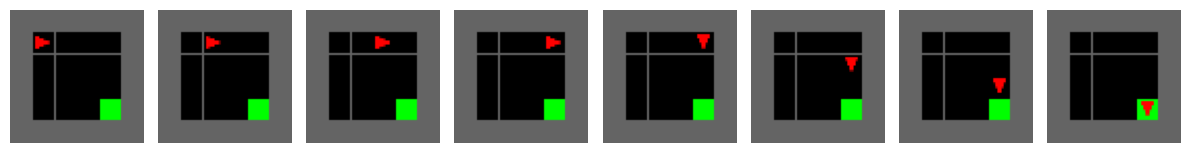

In [9]:
def collect_episodes(num_episodes, start_seed, policy):
    episodes = []
    env = make_env()
    for episode_index in tqdm(range(num_episodes), desc=f"collect {policy}"):
        seed = start_seed + episode_index
        rng = np.random.default_rng(seed)
        observation, info = env.reset(seed=seed)
        env.action_space.seed(seed)
        frames = [render_resized(env, cfg.image_size)]
        dirs = [int(env.unwrapped.agent_dir)]
        actions = []
        rewards = []
        continues = []
        dones = []
        for step in range(cfg.max_steps):
            action = choose_data_action(env, policy, rng)
            next_observation, reward, terminated, truncated, info = env.step(action)
            done = bool(terminated or truncated)
            frames.append(render_resized(env, cfg.image_size))
            dirs.append(int(env.unwrapped.agent_dir))
            actions.append(action)
            rewards.append(float(reward))
            continues.append(0.0 if done else 1.0)
            dones.append(done)
            if done:
                break
        episodes.append({
            "frames": np.asarray(frames, dtype=np.uint8),
            "dirs": np.asarray(dirs, dtype=np.int64),
            "actions": np.asarray(actions, dtype=np.int64),
            "rewards": np.asarray(rewards, dtype=np.float32),
            "continues": np.asarray(continues, dtype=np.float32),
            "dones": np.asarray(dones, dtype=np.bool_),
            "policy": policy,
        })
    env.close()
    return episodes

train_episodes = []
train_episodes += collect_episodes(cfg.random_dataset_episodes, cfg.seed * 1000, "random")
train_episodes += collect_episodes(cfg.oracle_dataset_episodes, cfg.seed * 1000 + 50000, "oracle")
val_episodes = []
val_episodes += collect_episodes(cfg.val_random_episodes, cfg.seed * 1000 + 100000, "random")
val_episodes += collect_episodes(cfg.val_oracle_episodes, cfg.seed * 1000 + 150000, "oracle")

lengths = [len(episode["actions"]) for episode in train_episodes]
returns = [episode["rewards"].sum() for episode in train_episodes]
print(len(train_episodes), np.mean(lengths), np.mean(returns), np.max(returns))
plot_frames([train_episodes[-1]["frames"][i] for i in range(min(8, len(train_episodes[-1]["frames"])))])

In [10]:
class EpisodeSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, episodes, sequence_length):
        self.episodes = [episode for episode in episodes if len(episode["actions"]) >= sequence_length]
        self.sequence_length = sequence_length
        self.index = []
        for episode_id, episode in enumerate(self.episodes):
            limit = len(episode["actions"]) - sequence_length + 1
            for start in range(limit):
                self.index.append((episode_id, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, item):
        episode_id, start = self.index[item]
        action_end = start + self.sequence_length
        frame_end = action_end + 1
        episode = self.episodes[episode_id]
        frames = torch.from_numpy(episode["frames"][start:frame_end]).float().permute(0, 3, 1, 2) / 255.0
        actions = torch.from_numpy(episode["actions"][start:action_end]).long()
        rewards = torch.from_numpy(episode["rewards"][start:action_end]).float()
        continues = torch.from_numpy(episode["continues"][start:action_end]).float()
        dirs = torch.from_numpy(episode["dirs"][start + 1:frame_end]).long()
        return frames, actions, rewards, continues, dirs

probe_env = make_env()
num_actions = probe_env.action_space.n
probe_env.close()
train_dataset = EpisodeSequenceDataset(train_episodes, cfg.sequence_length)
val_dataset = EpisodeSequenceDataset(val_episodes, cfg.sequence_length)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, drop_last=True)

print(num_actions, len(train_dataset), len(val_dataset))

7 14280 1289


In [11]:
class Encoder(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ELU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ELU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ELU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, embed_size),
            nn.ELU(),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, deter_size, latent_size):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(deter_size + latent_size, 256 * 4 * 4),
            nn.ELU(),
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
        )

    def forward(self, features):
        x = self.fc(features).view(features.shape[0], 256, 4, 4)
        return self.net(x)


class MLPHead(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, output_size),
        )

    def forward(self, x):
        return self.net(x)


class RSSMWorldModel(nn.Module):
    def __init__(self, num_actions, cfg):
        super().__init__()
        self.num_actions = num_actions
        self.latent_size = cfg.latent_size
        self.deter_size = cfg.deter_size
        self.encoder = Encoder(cfg.embed_size)
        self.action_embed = nn.Linear(num_actions, cfg.action_embed_size)
        self.gru = nn.GRUCell(cfg.latent_size + cfg.action_embed_size, cfg.deter_size)
        self.prior = MLPHead(cfg.deter_size, 2 * cfg.latent_size)
        self.posterior = MLPHead(cfg.deter_size + cfg.embed_size, 2 * cfg.latent_size)
        self.decoder = Decoder(cfg.deter_size, cfg.latent_size)
        self.reward_head = MLPHead(cfg.deter_size + cfg.latent_size, 1)
        self.continue_head = MLPHead(cfg.deter_size + cfg.latent_size, 1)
        self.dir_head = MLPHead(cfg.deter_size + cfg.latent_size, 4)

    def initial(self, batch_size, device):
        deter = torch.zeros(batch_size, self.deter_size, device=device)
        stoch = torch.zeros(batch_size, self.latent_size, device=device)
        return deter, stoch

    def distribution(self, stats):
        mean, std_raw = torch.chunk(stats, 2, dim=-1)
        std = F.softplus(std_raw) + 0.1
        return torch.distributions.Normal(mean, std)

    def transition(self, prev_stoch, action, prev_deter, sample=True):
        embedded_action = self.action_embed(action)
        x = torch.cat([prev_stoch, embedded_action], dim=-1)
        deter = self.gru(x, prev_deter)
        prior_dist = self.distribution(self.prior(deter))
        prior_stoch = prior_dist.rsample() if sample else prior_dist.mean
        return deter, prior_stoch, prior_dist

    def observe_step(self, prev_stoch, action, prev_deter, embed, sample=True):
        deter, prior_stoch, prior_dist = self.transition(prev_stoch, action, prev_deter, sample=sample)
        posterior_dist = self.distribution(self.posterior(torch.cat([deter, embed], dim=-1)))
        posterior_stoch = posterior_dist.rsample() if sample else posterior_dist.mean
        return deter, posterior_stoch, prior_stoch, posterior_dist, prior_dist

    def features(self, deter, stoch):
        return torch.cat([deter, stoch], dim=-1)

    def forward(self, frames, actions):
        batch_size, transition_length = actions.shape
        frame_length = frames.shape[1]
        embeds = self.encoder(frames.reshape(batch_size * frame_length, 3, cfg.image_size, cfg.image_size))
        embeds = embeds.reshape(batch_size, frame_length, -1)
        prev_deter, prev_stoch = self.initial(batch_size, frames.device)
        zero_action = torch.zeros(batch_size, self.num_actions, device=frames.device)
        prev_deter, prev_stoch, prior_stoch, posterior_dist, prior_dist = self.observe_step(prev_stoch, zero_action, prev_deter, embeds[:, 0])
        deter_list = []
        stoch_list = []
        prior_stoch_list = []
        posterior_list = []
        prior_list = []
        for t in range(transition_length):
            action = action_one_hot(actions[:, t], self.num_actions)
            deter, stoch, prior_stoch, posterior_dist, prior_dist = self.observe_step(prev_stoch, action, prev_deter, embeds[:, t + 1])
            deter_list.append(deter)
            stoch_list.append(stoch)
            prior_stoch_list.append(prior_stoch)
            posterior_list.append(posterior_dist)
            prior_list.append(prior_dist)
            prev_deter = deter
            prev_stoch = stoch
        deter = torch.stack(deter_list, dim=1)
        stoch = torch.stack(stoch_list, dim=1)
        prior_stoch = torch.stack(prior_stoch_list, dim=1)
        posterior_features = self.features(deter.reshape(batch_size * transition_length, -1), stoch.reshape(batch_size * transition_length, -1))
        prior_features = self.features(deter.reshape(batch_size * transition_length, -1), prior_stoch.reshape(batch_size * transition_length, -1))
        recon_logits = self.decoder(posterior_features).reshape(batch_size, transition_length, 3, cfg.image_size, cfg.image_size)
        prior_recon_logits = self.decoder(prior_features).reshape(batch_size, transition_length, 3, cfg.image_size, cfg.image_size)
        reward_pred = self.reward_head(posterior_features).reshape(batch_size, transition_length)
        prior_reward_pred = self.reward_head(prior_features).reshape(batch_size, transition_length)
        continue_logits = self.continue_head(posterior_features).reshape(batch_size, transition_length)
        prior_continue_logits = self.continue_head(prior_features).reshape(batch_size, transition_length)
        dir_logits = self.dir_head(posterior_features).reshape(batch_size, transition_length, 4)
        prior_dir_logits = self.dir_head(prior_features).reshape(batch_size, transition_length, 4)
        return {
            "recon_logits": recon_logits,
            "prior_recon_logits": prior_recon_logits,
            "reward_pred": reward_pred,
            "prior_reward_pred": prior_reward_pred,
            "continue_logits": continue_logits,
            "prior_continue_logits": prior_continue_logits,
            "dir_logits": dir_logits,
            "prior_dir_logits": prior_dir_logits,
            "posterior": posterior_list,
            "prior": prior_list,
            "deter": deter,
            "stoch": stoch,
            "prior_stoch": prior_stoch,
        }

    @torch.no_grad()
    def encode_observation(self, frame, state=None, prev_action=None):
        self.eval()
        if frame.ndim == 3:
            frame = frame[None]
        tensor = frame_to_tensor(frame).to(device)
        embed = self.encoder(tensor)
        if state is None:
            prev_deter, prev_stoch = self.initial(tensor.shape[0], tensor.device)
        else:
            prev_deter, prev_stoch = state
        if prev_action is None:
            action = torch.zeros(tensor.shape[0], self.num_actions, device=tensor.device)
        else:
            action = action_one_hot(torch.as_tensor(prev_action, device=tensor.device), self.num_actions)
        deter, stoch, prior_stoch, posterior_dist, prior_dist = self.observe_step(prev_stoch, action, prev_deter, embed, sample=False)
        return deter, stoch

    @torch.no_grad()
    def imagine(self, state, action_sequences):
        self.eval()
        candidate_count, horizon = action_sequences.shape
        prev_deter, prev_stoch = state
        prev_deter = prev_deter.repeat(candidate_count, 1)
        prev_stoch = prev_stoch.repeat(candidate_count, 1)
        frames = []
        rewards = []
        continues = []
        dirs = []
        for t in range(horizon):
            action = action_one_hot(action_sequences[:, t].to(prev_deter.device), self.num_actions)
            deter, stoch, prior_dist = self.transition(prev_stoch, action, prev_deter, sample=False)
            features = self.features(deter, stoch)
            frame = torch.sigmoid(self.decoder(features))
            reward = self.reward_head(features).squeeze(-1)
            continue_prob = torch.sigmoid(self.continue_head(features).squeeze(-1))
            direction = self.dir_head(features)
            frames.append(frame)
            rewards.append(reward)
            continues.append(continue_prob)
            dirs.append(direction)
            prev_deter = deter
            prev_stoch = stoch
        return torch.stack(frames, dim=1), torch.stack(rewards, dim=1), torch.stack(continues, dim=1), torch.stack(dirs, dim=1)

world_model = RSSMWorldModel(num_actions, cfg).to(device)
print(sum(parameter.numel() for parameter in world_model.parameters()))

4397705


In [12]:
def weighted_reconstruction_loss(logits, target_frames):
    red_mask = target_frames[:, :, 0:1] > target_frames[:, :, 1:2] + 0.15
    green_mask = target_frames[:, :, 1:2] > target_frames[:, :, 0:1] + 0.15
    pixel_weight = 1.0 + 6.0 * red_mask.float() + 3.0 * green_mask.float()
    pixel_loss = F.binary_cross_entropy_with_logits(logits, target_frames, reduction="none")
    return (pixel_loss * pixel_weight).mean()


def compute_world_model_loss(model, batch):
    frames, actions, rewards, continues, dirs = [item.to(device) for item in batch]
    outputs = model(frames, actions)
    target_frames = frames[:, 1:]
    recon_loss = weighted_reconstruction_loss(outputs["recon_logits"], target_frames)
    prior_recon_loss = weighted_reconstruction_loss(outputs["prior_recon_logits"], target_frames)
    reward_loss = 0.5 * (F.mse_loss(outputs["reward_pred"], rewards) + F.mse_loss(outputs["prior_reward_pred"], rewards))
    continue_loss = 0.5 * (F.binary_cross_entropy_with_logits(outputs["continue_logits"], continues) + F.binary_cross_entropy_with_logits(outputs["prior_continue_logits"], continues))
    dir_loss = 0.5 * (F.cross_entropy(outputs["dir_logits"].reshape(-1, 4), dirs.reshape(-1)) + F.cross_entropy(outputs["prior_dir_logits"].reshape(-1, 4), dirs.reshape(-1)))
    kl_terms = []
    for posterior, prior in zip(outputs["posterior"], outputs["prior"]):
        kl = torch.distributions.kl_divergence(posterior, prior).sum(-1)
        kl = torch.maximum(kl, torch.ones_like(kl) * cfg.free_nats)
        kl_terms.append(kl.mean())
    kl_loss = torch.stack(kl_terms).mean()
    loss = recon_loss + cfg.prior_recon_scale * prior_recon_loss + cfg.reward_scale * reward_loss + cfg.continue_scale * continue_loss + cfg.direction_scale * dir_loss + cfg.kl_scale * kl_loss
    return loss, {
        "loss": loss.detach().item(),
        "recon": recon_loss.detach().item(),
        "prior_recon": prior_recon_loss.detach().item(),
        "reward": reward_loss.detach().item(),
        "continue": continue_loss.detach().item(),
        "direction": dir_loss.detach().item(),
        "kl": kl_loss.detach().item(),
    }


def cycle(loader):
    while True:
        for batch in loader:
            yield batch

optimizer = torch.optim.Adam(world_model.parameters(), lr=cfg.learning_rate)
train_iter = cycle(train_loader)
history = defaultdict(list)
world_model.train()

progress = tqdm(range(1, cfg.train_steps + 1), desc="train")
for step in progress:
    batch = next(train_iter)
    optimizer.zero_grad(set_to_none=True)
    loss, metrics = compute_world_model_loss(world_model, batch)
    loss.backward()
    nn.utils.clip_grad_norm_(world_model.parameters(), cfg.grad_clip)
    optimizer.step()
    for key, value in metrics.items():
        history[key].append(value)
    if step % 50 == 0:
        progress.set_postfix({key: f"{np.mean(values[-50:]):.4f}" for key, values in history.items()})

checkpoint = {
    "model": world_model.state_dict(),
    "config": cfg.__dict__,
    "num_actions": num_actions,
    "history": dict(history),
}
torch.save(checkpoint, output_dir / "checkpoints" / "rssm_world_model.pt")

train:   0%|          | 0/6000 [00:00<?, ?it/s]

In [13]:
returns = np.array([episode["rewards"].sum() for episode in train_episodes])
print("successful episodes:", np.sum(returns > 0), "/", len(returns))
print("mean return:", returns.mean())
print("max return:", returns.max())
print("nonzero reward transitions:", sum((episode["rewards"] > 0).sum() for episode in train_episodes))

successful episodes: 280 / 700
mean return: 0.33171654
max return: 0.9015625
nonzero reward transitions: 280


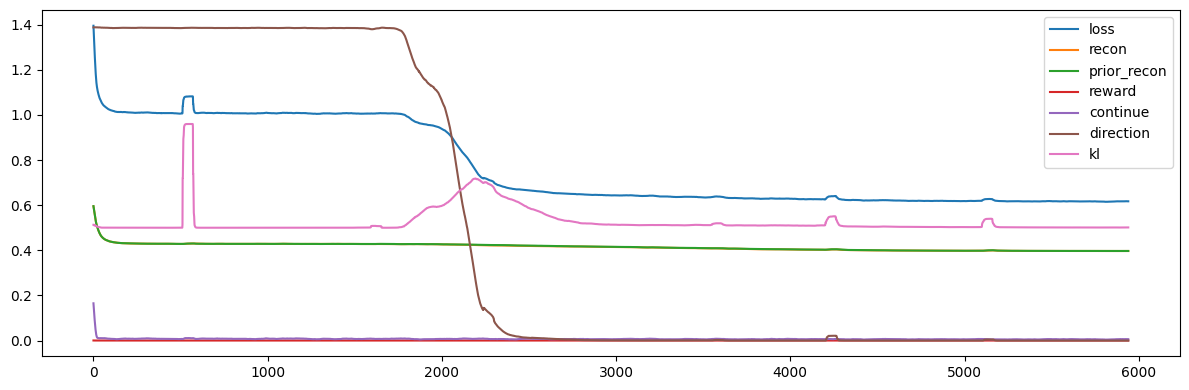

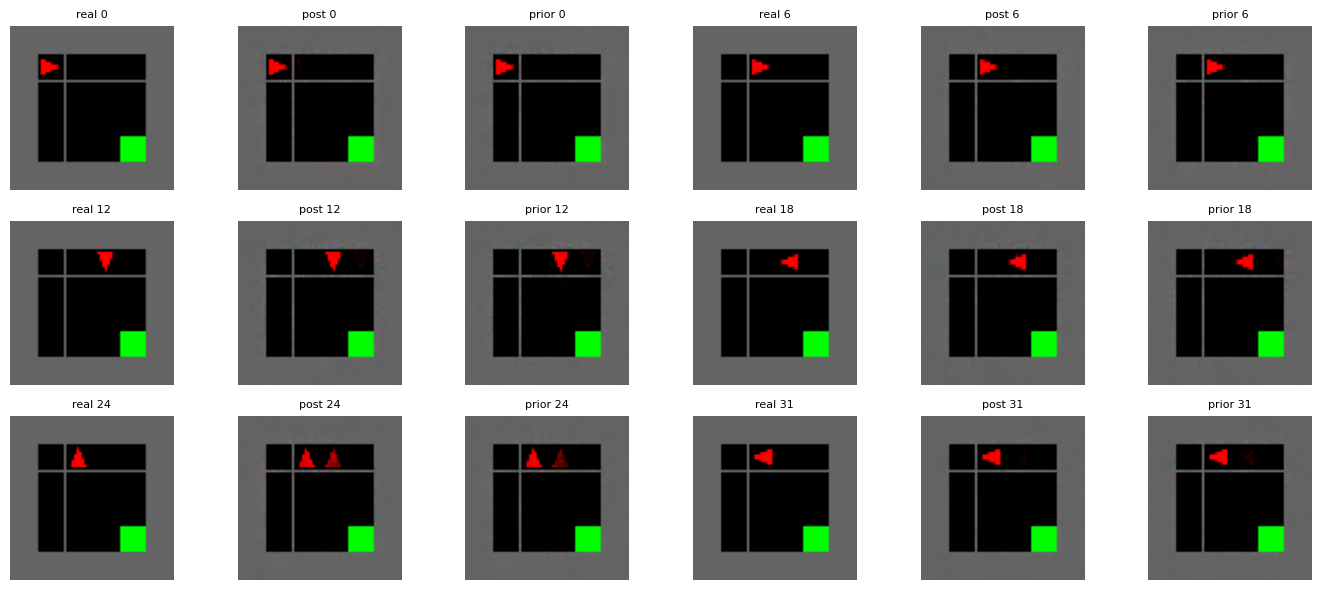

In [18]:
plt.figure(figsize=(12, 4))
for key in ["loss", "recon", "prior_recon", "reward", "continue", "direction", "kl"]:
    values = np.asarray(history[key], dtype=np.float32)
    window = max(1, len(values) // 100)
    smoothed = np.convolve(values, np.ones(window) / window, mode="valid")
    plt.plot(smoothed, label=key)
plt.legend()
plt.tight_layout()
plt.show()

world_model.eval()
with torch.no_grad():
    batch = next(iter(val_loader))
    frames, actions, rewards, continues, dirs = [item.to(device) for item in batch]
    outputs = world_model(frames[:1], actions[:1])
    recon = torch.sigmoid(outputs["recon_logits"])[0].detach().cpu().permute(0, 2, 3, 1).numpy()
    prior_recon = torch.sigmoid(outputs["prior_recon_logits"])[0].detach().cpu().permute(0, 2, 3, 1).numpy()
    real = frames[0, 1:].detach().cpu().permute(0, 2, 3, 1).numpy()

indices = np.linspace(0, cfg.sequence_length - 1, 6).astype(int)
comparison = []
titles = []
for index in indices:
    comparison.append((real[index] * 255).astype(np.uint8))
    titles.append(f"real {index}")
    comparison.append((recon[index] * 255).astype(np.uint8))
    titles.append(f"post {index}")
    comparison.append((prior_recon[index] * 255).astype(np.uint8))
    titles.append(f"prior {index}")
plot_frames(comparison, titles=titles, columns=6, figsize=(14, 6))

In [19]:
class CLIPScorer:
    def __init__(self, device, model_name="openai/clip-vit-base-patch32"):
        self.device = device
        self.model = CLIPModel.from_pretrained(model_name).to(device)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model.eval()
        for parameter in self.model.parameters():
            parameter.requires_grad_(False)
        positive_prompts = [
            "a red triangle inside a bright green square",
            "a red arrow overlapping a green square",
            "a red agent on top of the green goal cell",
            "the green square contains the red agent",
        ]
        negative_prompts = [
            "an empty bright green square",
            "a green square without a red triangle inside",
            "a red triangle next to the green square but outside it",
            "a red arrow near a green square but not overlapping it",
        ]
        with torch.no_grad():
            self.positive = self.encode_text(positive_prompts)
            self.negative = self.encode_text(negative_prompts)

    @torch.no_grad()
    def encode_text(self, prompts):
        inputs = self.processor(text=prompts, return_tensors="pt", padding=True)
        input_ids = inputs["input_ids"].to(self.device)
        attention_mask = inputs["attention_mask"].to(self.device)
        outputs = self.model.text_model(input_ids=input_ids, attention_mask=attention_mask)
        features = self.model.text_projection(outputs.pooler_output).float()
        return features / features.norm(dim=-1, keepdim=True)

    def sharpen_frames(self, frames):
        return torch.clamp((frames - 0.5) * 1.4 + 0.5, 0.0, 1.0)

    def crop_goal_region(self, frames, pad=12):
        crops = []
        _, _, height, width = frames.shape
        for frame in frames:
            green = frame[1] > frame[0] + 0.2
            ys, xs = torch.where(green)
            if len(xs) == 0:
                crops.append(frame)
                continue
            x1 = max(int(xs.min().item()) - pad, 0)
            x2 = min(int(xs.max().item()) + pad + 1, width)
            y1 = max(int(ys.min().item()) - pad, 0)
            y2 = min(int(ys.max().item()) + pad + 1, height)
            crop = frame[:, y1:y2, x1:x2]
            crop = F.interpolate(crop.unsqueeze(0), size=(cfg.image_size, cfg.image_size), mode="nearest").squeeze(0)
            crops.append(crop)
        return torch.stack(crops, dim=0)

    @torch.no_grad()
    def score_tensor(self, frames, use_goal_crop=True):
        original_shape = frames.shape[:-3]
        flat = frames.reshape(-1, *frames.shape[-3:])
        if use_goal_crop:
            flat = self.crop_goal_region(flat)
        flat = self.sharpen_frames(flat)
        score_chunks = []
        mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=frames.device).view(1, 3, 1, 1)
        std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=frames.device).view(1, 3, 1, 1)
        for start in range(0, flat.shape[0], cfg.vlm_batch_size):
            batch = flat[start:start + cfg.vlm_batch_size]
            resized = F.interpolate(batch, size=(cfg.vlm_image_size, cfg.vlm_image_size), mode="nearest")
            normalized = (resized - mean) / std
            outputs = self.model.vision_model(pixel_values=normalized)
            image_features = self.model.visual_projection(outputs.pooler_output).float()
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            scale = self.model.logit_scale.exp().to(image_features.device)
            positive_logits = scale * (image_features @ self.positive.T)
            negative_logits = scale * (image_features @ self.negative.T)
            scores = positive_logits.max(dim=1).values - negative_logits.max(dim=1).values
            score_chunks.append(scores)
        return torch.cat(score_chunks, dim=0).reshape(original_shape)


class CLIPScorerVariant:
    def __init__(self, scorer, use_goal_crop):
        self.scorer = scorer
        self.use_goal_crop = use_goal_crop

    def score_tensor(self, frames):
        return self.scorer.score_tensor(frames, use_goal_crop=self.use_goal_crop)

base_vlm_scorer = CLIPScorer(device)
vlm_scorer = CLIPScorerVariant(base_vlm_scorer, use_goal_crop=True)
full_frame_vlm_scorer = CLIPScorerVariant(base_vlm_scorer, use_goal_crop=False)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

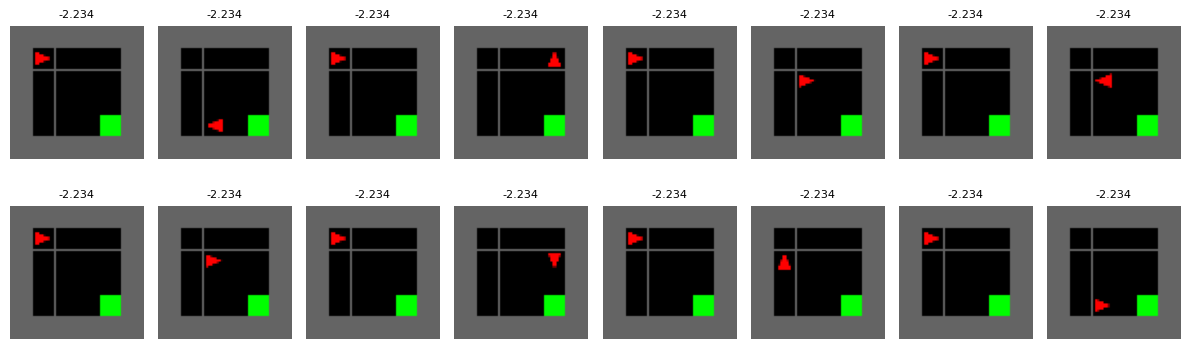

-2.233795166015625 -2.233795166015625 -2.233795166015625


In [28]:
sample_frames = []
for episode in train_episodes[:12] + train_episodes[-12:]:
    if len(sample_frames) >= 16:
        break
    frame_indices = np.linspace(0, len(episode["frames"]) - 1, min(2, len(episode["frames"]))).astype(int)
    for frame_index in frame_indices:
        sample_frames.append(episode["frames"][frame_index])

with torch.no_grad():
    tensor = frame_to_tensor(sample_frames).to(device)
    scores = vlm_scorer.score_tensor(tensor).detach().cpu().numpy()

titles = [f"{score:.3f}" for score in scores]
plot_frames(sample_frames, titles=titles, columns=8, figsize=(12, 4))
print(float(scores.min()), float(scores.mean()), float(scores.max()))

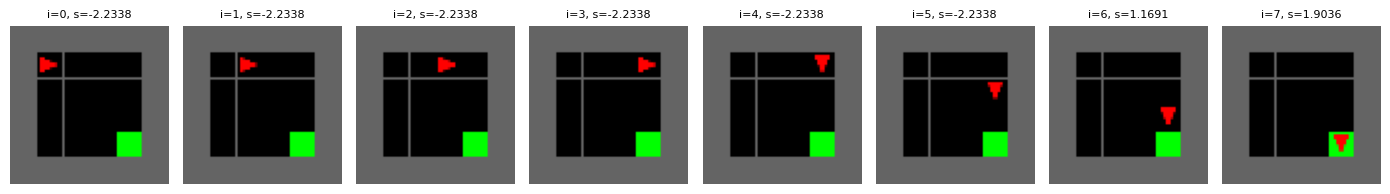

[(0, -2.233799934387207), (1, -2.233799934387207), (2, -2.233799934387207), (3, -2.233799934387207), (4, -2.233799934387207), (5, -2.233799934387207), (6, 1.169100046157837), (7, 1.9035999774932861)]
return: 0.9015625


In [21]:
episode = max(train_episodes, key=lambda e: e["rewards"].sum())
indices = np.linspace(0, len(episode["frames"]) - 1, 8).astype(int)
frames = [episode["frames"][i] for i in indices]

with torch.no_grad():
    tensor = frame_to_tensor(frames).to(device)
    scores = vlm_scorer.score_tensor(tensor).detach().cpu().numpy()

titles = [f"i={i}, s={s:.4f}" for i, s in zip(indices, scores)]
plot_frames(frames, titles=titles, columns=8, figsize=(14, 3))
print(list(zip(indices.tolist(), scores.round(4).tolist())))
print("return:", episode["rewards"].sum())

In [29]:
class RandomAgent:
    def __init__(self, action_ids):
        self.action_ids = list(action_ids)

    def act(self, frame):
        return int(random.choice(self.action_ids))


class MPCPlanner:
    def __init__(self, model, num_actions, scorer=None, objective="reward"):
        self.model = model
        self.num_actions = num_actions
        self.scorer = scorer
        self.objective = objective
        self.state = None
        self.prev_action = None
        self.allowed_actions = torch.tensor(cfg.planner_action_ids, dtype=torch.long, device=device)

    def reset(self):
        self.state = None
        self.prev_action = None

    @torch.no_grad()
    def act(self, frame):
        self.state = self.model.encode_observation(frame, self.state, self.prev_action)
        candidate_indices = torch.randint(
            low=0,
            high=len(cfg.planner_action_ids),
            size=(cfg.planning_candidates, cfg.planning_horizon),
            device=device,
        )
        candidates = self.allowed_actions[candidate_indices]
        imagined_frames, imagined_rewards, imagined_continues, imagined_dirs = self.model.imagine(self.state, candidates)
        discounts = (cfg.gamma ** torch.arange(cfg.planning_horizon, device=device).float()).view(1, -1)
        survival = torch.cumprod(torch.cat([torch.ones_like(imagined_continues[:, :1]), imagined_continues[:, :-1]], dim=1), dim=1)
        time_cost = (discounts * survival).sum(dim=1)
        turn_cost = (discounts * (candidates != 2).float()).sum(dim=1)
        task_reward_objective = (discounts * imagined_rewards).sum(dim=1)
        reward_objective = task_reward_objective - cfg.time_penalty * time_cost - cfg.turn_penalty * turn_cost
        if self.objective == "reward":
            best = int(torch.argmax(reward_objective).item())
        else:
            topk = min(cfg.vlm_rerank, cfg.planning_candidates)
            top_values, top_indices = torch.topk(reward_objective, k=topk)
            top_frames = imagined_frames[top_indices]
            score_count = min(cfg.vlm_score_frames, cfg.planning_horizon)
            score_indices = torch.linspace(0, cfg.planning_horizon - 1, score_count, device=device).long()
            scored_frames = top_frames[:, score_indices]
            vlm_scores = self.scorer.score_tensor(scored_frames.reshape(-1, 3, cfg.image_size, cfg.image_size))
            vlm_scores = vlm_scores.reshape(topk, score_count)
            vlm_objective = vlm_scores[:, -3:].max(dim=1).values
            reward_norm = (top_values - top_values.mean()) / (top_values.std() + 1e-6)
            vlm_norm = (vlm_objective - vlm_objective.mean()) / (vlm_objective.std() + 1e-6)
            if self.objective == "vlm":
                rerank_objective = vlm_norm
            else:
                rerank_objective = cfg.reward_weight * reward_norm + cfg.vlm_weight * vlm_norm
            best_local = int(torch.argmax(rerank_objective).item())
            best = int(top_indices[best_local].item())
        action = int(candidates[best, 0].item())
        self.prev_action = torch.tensor([action], device=device)
        return action

In [30]:
def run_episode(agent, seed, save_frames=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    env = make_env(seed=seed)
    observation, info = env.reset(seed=seed)
    env.action_space.seed(seed)
    if hasattr(agent, "reset"):
        agent.reset()
    total_reward = 0.0
    frames = []
    success = False
    for step in range(cfg.max_steps):
        frame = render_resized(env, cfg.image_size)
        if save_frames:
            frames.append(render_resized(env, 160))
        action = agent.act(frame)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        done = bool(terminated or truncated)
        if terminated and reward > 0:
            success = True
        if done:
            if save_frames:
                frames.append(render_resized(env, 160))
            break
    env.close()
    return {
        "return": total_reward,
        "length": step + 1,
        "success": float(success),
        "frames": frames,
    }


def evaluate_agent(agent_factory, seeds, name):
    results = []
    for seed in tqdm(seeds, desc=name):
        agent = agent_factory()
        result = run_episode(agent, seed, save_frames=False)
        results.append(result)
    metrics = {
        "name": name,
        "episodes": len(results),
        "success_rate": float(np.mean([item["success"] for item in results])),
        "mean_return": float(np.mean([item["return"] for item in results])),
        "mean_length": float(np.mean([item["length"] for item in results])),
    }
    return metrics, results

seeds = list(range(2000, 2000 + cfg.eval_episodes))
agents = {
    "random": lambda: RandomAgent(cfg.planner_action_ids),
    "world_model_reward": lambda: MPCPlanner(world_model, num_actions, scorer=None, objective="reward"),
    "world_model_vlm": lambda: MPCPlanner(world_model, num_actions, scorer=vlm_scorer, objective="mixed"),
}

all_metrics = []
all_results = {}
for name, factory in agents.items():
    metrics, results = evaluate_agent(factory, seeds, name)
    all_metrics.append(metrics)
    all_results[name] = results

for metrics in all_metrics:
    print(metrics)

np.save(output_dir / "metrics" / "evaluation_metrics.npy", np.asarray(all_metrics, dtype=object), allow_pickle=True)
main_cfg = cfg
main_world_model = world_model
main_train_episodes = train_episodes
main_val_episodes = val_episodes
main_train_loader = train_loader
main_val_loader = val_loader
main_history = history
main_output_dir = output_dir
main_metrics = all_metrics
main_results = all_results

random:   0%|          | 0/20 [00:00<?, ?it/s]

world_model_reward:   0%|          | 0/20 [00:00<?, ?it/s]

world_model_vlm:   0%|          | 0/20 [00:00<?, ?it/s]

{'name': 'random', 'episodes': 20, 'success_rate': 0.4, 'mean_return': 0.172890625, 'mean_length': 54.55}
{'name': 'world_model_reward', 'episodes': 20, 'success_rate': 0.85, 'mean_return': 0.5532812500000001, 'mean_length': 30.7}
{'name': 'world_model_vlm', 'episodes': 20, 'success_rate': 0.9, 'mean_return': 0.5927343749999999, 'mean_length': 28.25}


In [31]:
ablation_agents = {
    "world_model_reward": lambda: MPCPlanner(world_model, num_actions, scorer=None, objective="reward"),
    "world_model_vlm_full_frame": lambda: MPCPlanner(world_model, num_actions, scorer=full_frame_vlm_scorer, objective="mixed"),
    "world_model_vlm_goal_crop": lambda: MPCPlanner(world_model, num_actions, scorer=vlm_scorer, objective="mixed"),
}

ablation_metrics = []
ablation_results = {}
for name, factory in ablation_agents.items():
    metrics, results = evaluate_agent(factory, seeds, name)
    ablation_metrics.append(metrics)
    ablation_results[name] = results

for metrics in ablation_metrics:
    print(metrics)

np.save(output_dir / "metrics" / "ablation_metrics.npy", np.asarray(ablation_metrics, dtype=object), allow_pickle=True)

world_model_reward:   0%|          | 0/20 [00:00<?, ?it/s]

world_model_vlm_full_frame:   0%|          | 0/20 [00:00<?, ?it/s]

world_model_vlm_goal_crop:   0%|          | 0/20 [00:00<?, ?it/s]

{'name': 'world_model_reward', 'episodes': 20, 'success_rate': 0.85, 'mean_return': 0.5532812500000001, 'mean_length': 30.7}
{'name': 'world_model_vlm_full_frame', 'episodes': 20, 'success_rate': 0.8, 'mean_return': 0.45406250000000004, 'mean_length': 37.4}
{'name': 'world_model_vlm_goal_crop', 'episodes': 20, 'success_rate': 0.9, 'mean_return': 0.5927343749999999, 'mean_length': 28.25}


In [32]:
gif_seed = 9999
for name, factory in agents.items():
    agent = factory()
    result = run_episode(agent, gif_seed, save_frames=True)
    path = output_dir / "gifs" / f"{name}.gif"
    imageio.mimsave(path, result["frames"], duration=0.12)
    print(name, path, result["return"], result["length"], result["success"])

random /kaggle/working/outputs/gifs/random.gif 0.0 64 0.0
world_model_reward /kaggle/working/outputs/gifs/world_model_reward.gif 0.7609375 17 1.0
world_model_vlm /kaggle/working/outputs/gifs/world_model_vlm.gif 0.7609375 17 1.0


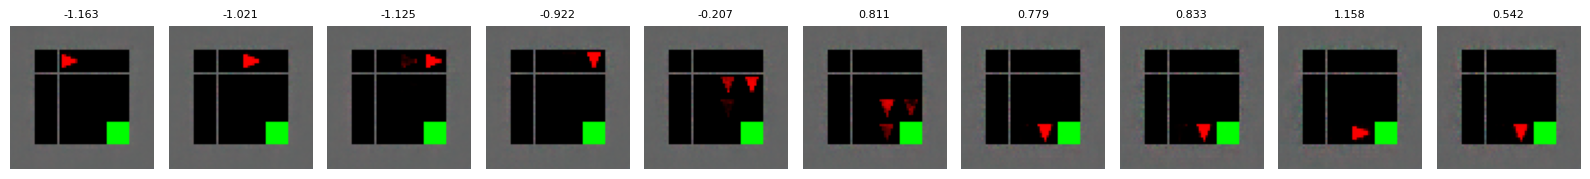

In [41]:
env = make_env(seed=4242)
observation, info = env.reset(seed=4242)
current_frame = render_resized(env, cfg.image_size)
planner = MPCPlanner(world_model, num_actions, scorer=vlm_scorer, objective="mixed")
planner.state = world_model.encode_observation(current_frame, None, None)
with torch.no_grad():
    allowed_actions = torch.tensor(cfg.planner_action_ids, dtype=torch.long, device=device)
    candidate_indices = torch.randint(0, len(cfg.planner_action_ids), (cfg.planning_candidates, cfg.planning_horizon), device=device)
    candidates = allowed_actions[candidate_indices]
    imagined_frames, imagined_rewards, imagined_continues, imagined_dirs = world_model.imagine(planner.state, candidates)
    discounts = (cfg.gamma ** torch.arange(cfg.planning_horizon, device=device).float()).view(1, -1)
    survival = torch.cumprod(torch.cat([torch.ones_like(imagined_continues[:, :1]), imagined_continues[:, :-1]], dim=1), dim=1)
    time_cost = (discounts * survival).sum(dim=1)
    turn_cost = (discounts * (candidates != 2).float()).sum(dim=1)
    task_reward_objective = (discounts * imagined_rewards).sum(dim=1)
    reward_objective = task_reward_objective - cfg.time_penalty * time_cost - cfg.turn_penalty * turn_cost
    topk = min(cfg.vlm_rerank, cfg.planning_candidates)
    top_values, top_indices = torch.topk(reward_objective, k=topk)
    top_frames = imagined_frames[top_indices]
    score_count = min(cfg.vlm_score_frames, cfg.planning_horizon)
    score_indices = torch.linspace(0, cfg.planning_horizon - 1, score_count, device=device).long()
    scored_frames = top_frames[:, score_indices]
    vlm_scores = vlm_scorer.score_tensor(scored_frames.reshape(-1, 3, cfg.image_size, cfg.image_size))
    vlm_scores = vlm_scores.reshape(topk, score_count)
    vlm_objective = vlm_scores[:, -3:].max(dim=1).values
    reward_norm = (top_values - top_values.mean()) / (top_values.std() + 1e-6)
    vlm_norm = (vlm_objective - vlm_objective.mean()) / (vlm_objective.std() + 1e-6)
    rerank_objective = cfg.reward_weight * reward_norm + cfg.vlm_weight * vlm_norm
    best_local = int(torch.argmax(rerank_objective).item())
    best = int(top_indices[best_local].item())
    rollout_tensor = imagined_frames[best]
    score_values = vlm_scorer.score_tensor(rollout_tensor).detach().cpu().numpy()
    rollout = rollout_tensor.detach().cpu().permute(0, 2, 3, 1).numpy()
frames = [(frame * 255).astype(np.uint8) for frame in rollout]
titles = [f"{value:.3f}" for value in score_values]
plot_frames(frames, titles=titles, columns=cfg.planning_horizon, figsize=(16, 2))
env.close()

In [42]:
report_dir = main_output_dir / "report_assets"
report_dir.mkdir(parents=True, exist_ok=True)


def save_grid_image(frames, titles, path, columns=8, figsize=(12, 4)):
    rows = int(np.ceil(len(frames) / columns))
    plt.figure(figsize=figsize)
    for index, frame in enumerate(frames):
        plt.subplot(rows, columns, index + 1)
        plt.imshow(frame)
        plt.axis("off")
        if titles is not None:
            plt.title(titles[index], fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()


def save_metrics_plot(metrics, path, title):
    names = [item["name"] for item in metrics]
    success = [item["success_rate"] for item in metrics]
    returns = [item["mean_return"] for item in metrics]
    lengths = [item["mean_length"] for item in metrics]
    x = np.arange(len(names))
    plt.figure(figsize=(max(8, len(names) * 1.8), 4))
    plt.subplot(1, 3, 1)
    plt.bar(x, success)
    plt.xticks(x, names, rotation=35, ha="right")
    plt.ylim(0, 1.0)
    plt.title("success rate")
    plt.subplot(1, 3, 2)
    plt.bar(x, returns)
    plt.xticks(x, names, rotation=35, ha="right")
    plt.title("mean return")
    plt.subplot(1, 3, 3)
    plt.bar(x, lengths)
    plt.xticks(x, names, rotation=35, ha="right")
    plt.title("mean length")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()


def save_training_plot(metric_history, path, title):
    plt.figure(figsize=(12, 4))
    for key in ["loss", "recon", "prior_recon", "reward", "continue", "direction", "kl"]:
        if key in metric_history:
            values = np.asarray(metric_history[key], dtype=np.float32)
            window = max(1, len(values) // 100)
            smoothed = np.convolve(values, np.ones(window) / window, mode="valid")
            plt.plot(smoothed, label=key)
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()


save_training_plot(main_history, report_dir / "main_training_curves.png", "MiniGrid Empty 6x6 training")
save_metrics_plot(main_metrics, report_dir / "main_evaluation_metrics.png", "MiniGrid Empty 6x6 evaluation")
if "ablation_metrics" in globals():
    save_metrics_plot(ablation_metrics, report_dir / "vlm_ablation_metrics.png", "VLM ablation")

main_world_model.eval()
with torch.no_grad():
    batch = next(iter(main_val_loader))
    frames, actions, rewards, continues, dirs = [item.to(device) for item in batch]
    outputs = main_world_model(frames[:1], actions[:1])
    posterior = torch.sigmoid(outputs["recon_logits"])[0].detach().cpu().permute(0, 2, 3, 1).numpy()
    prior = torch.sigmoid(outputs["prior_recon_logits"])[0].detach().cpu().permute(0, 2, 3, 1).numpy()
    real = frames[0, 1:].detach().cpu().permute(0, 2, 3, 1).numpy()
indices = np.linspace(0, main_cfg.sequence_length - 1, 6).astype(int)
comparison = []
titles = []
for index in indices:
    comparison.append((real[index] * 255).astype(np.uint8))
    titles.append(f"real {index}")
    comparison.append((posterior[index] * 255).astype(np.uint8))
    titles.append(f"post {index}")
    comparison.append((prior[index] * 255).astype(np.uint8))
    titles.append(f"prior {index}")
save_grid_image(comparison, titles, report_dir / "world_model_reconstructions.png", columns=6, figsize=(14, 6))

episode = max(main_train_episodes, key=lambda item: item["rewards"].sum())
indices = np.linspace(0, len(episode["frames"]) - 1, 8).astype(int)
frames = [episode["frames"][index] for index in indices]
with torch.no_grad():
    tensor = frame_to_tensor(frames).to(device)
    crop_scores = vlm_scorer.score_tensor(tensor).detach().cpu().numpy()
    full_scores = full_frame_vlm_scorer.score_tensor(tensor).detach().cpu().numpy()
save_grid_image(frames, [f"i={i}, s={s:.2f}" for i, s in zip(indices, crop_scores)], report_dir / "vlm_goal_crop_sanity.png", columns=8, figsize=(14, 3))
save_grid_image(frames, [f"i={i}, s={s:.2f}" for i, s in zip(indices, full_scores)], report_dir / "vlm_full_frame_sanity.png", columns=8, figsize=(14, 3))

env = make_env(seed=4242)
observation, info = env.reset(seed=4242)
current_frame = render_resized(env, main_cfg.image_size)
state = main_world_model.encode_observation(current_frame, None, None)
with torch.no_grad():
    allowed_actions = torch.tensor(main_cfg.planner_action_ids, dtype=torch.long, device=device)
    candidate_indices = torch.randint(0, len(main_cfg.planner_action_ids), (main_cfg.planning_candidates, main_cfg.planning_horizon), device=device)
    candidates = allowed_actions[candidate_indices]
    imagined_frames, imagined_rewards, imagined_continues, imagined_dirs = main_world_model.imagine(state, candidates)
    discounts = (main_cfg.gamma ** torch.arange(main_cfg.planning_horizon, device=device).float()).view(1, -1)
    survival = torch.cumprod(torch.cat([torch.ones_like(imagined_continues[:, :1]), imagined_continues[:, :-1]], dim=1), dim=1)
    reward_objective = (discounts * imagined_rewards).sum(dim=1) - main_cfg.time_penalty * (discounts * survival).sum(dim=1) - main_cfg.turn_penalty * (discounts * (candidates != 2).float()).sum(dim=1)
    topk = min(main_cfg.vlm_rerank, main_cfg.planning_candidates)
    top_values, top_indices = torch.topk(reward_objective, k=topk)
    top_frames = imagined_frames[top_indices]
    score_count = min(main_cfg.vlm_score_frames, main_cfg.planning_horizon)
    score_indices = torch.linspace(0, main_cfg.planning_horizon - 1, score_count, device=device).long()
    scored_frames = top_frames[:, score_indices]
    vlm_scores = vlm_scorer.score_tensor(scored_frames.reshape(-1, 3, main_cfg.image_size, main_cfg.image_size)).reshape(topk, score_count)
    vlm_objective = vlm_scores[:, -3:].max(dim=1).values
    reward_norm = (top_values - top_values.mean()) / (top_values.std() + 1e-6)
    vlm_norm = (vlm_objective - vlm_objective.mean()) / (vlm_objective.std() + 1e-6)
    best = int(top_indices[int(torch.argmax(main_cfg.reward_weight * reward_norm + main_cfg.vlm_weight * vlm_norm).item())].item())
    rollout_tensor = imagined_frames[best]
    rollout_scores = vlm_scorer.score_tensor(rollout_tensor).detach().cpu().numpy()
    rollout = rollout_tensor.detach().cpu().permute(0, 2, 3, 1).numpy()
env.close()
save_grid_image([(frame * 255).astype(np.uint8) for frame in rollout], [f"{score:.2f}" for score in rollout_scores], report_dir / "imagined_rollout_vlm_scores.png", columns=main_cfg.planning_horizon, figsize=(16, 2.4))

for gif_path in (main_output_dir / "gifs").glob("*.gif"):
    shutil.copy2(gif_path, report_dir / gif_path.name)
for screenshot_path in Path("media/screenshots").glob("*.png"):
    shutil.copy2(screenshot_path, report_dir / screenshot_path.name)

zip_base = work_dir / "outputs"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", main_output_dir))
print(report_dir)
print(zip_path, zip_path.exists(), zip_path.stat().st_size)
display(FileLink(zip_path.name))

/kaggle/working/outputs/report_assets
/kaggle/working/outputs.zip True 16879846


/kaggle/working/outputs.zip